# Homework 3
### PSTAT 131/231
### free late submission

## Binary Classification
For this assignment, we will be working with part of a [Kaggle dataset](https://www.kaggle.com/c/titanic/overview) that was the subject of a machine learning competition and is often used for practicing ML models. The goal is classification; specifically, to predict which passengers would survive the [Titanic shipwreck](https://en.wikipedia.org/wiki/Titanic)

For starters import pandas, numpy, matplotlib and seaborn. Then load in the data and familiarize yourself with it by reading the codebook present in the data subdirectory. 

After loading in the data, take a prief look at it using [.head()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html). Take notice that later on we will need to encode `survived` and `pclass` variables.

In [95]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# Import numpy, pandas, matplotlib.pyplot and seaborn with the usual alias'. Then read in the data. 

np.random.seed(123)
# Set np.random.seed

df = pd.read_csv("/Users/karla-12/Desktop/homework-3-python/data/titanic.csv")
df.head()
# Load in the data and call .head()

,passenger_id,survived,pclass,name,sex,age,sib_sp,parch,ticket,fare,cabin,embarked
0,1,No,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,Yes,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,Yes,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,Yes,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,No,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Question 1
Drop the name, ticket, cabin and embarked columns as they will not be used for this assignment. Then take a look at the data and note any potential issues, such as missing values. 

Checking and getting counts for missing values in pandas can be done using [isna()](https://pandas.pydata.org/docs/reference/api/pandas.isna.html) and [sum()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html). 

In [96]:
df = df.drop(columns=['name', 'ticket', 'cabin', 'embarked'])
df.head()
df.isna().sum()


passenger_id      0
survived          0
pclass            0
sex               0
age             177
sib_sp            0
parch             0
fare              0
dtype: int64

### Question 2
Split the data into training and testing splits, stratifying on the outcome variable, `survived`. You should choose the proportions to split the data into. Verify that the training and testing datasets have the appropriate number of observations by using the native python `len` function.

After you have split the data into training and testing splits, write out why it is a good idea to use stratified sampling for this data.

In [97]:
from sklearn.model_selection import train_test_split

# Split the data
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['survived'],
    random_state=123
)

print(len(train_df))
print(len(test_df))

712
179


It is a good idea to use stratified sampling because estimation parameters tend to be more precise, guaranteeing that smaller subgroups are included in the estimation. Furthermore, it ensures that the proportion of passengers who survived versus did not survive remains similar in both the training and testing sets. This works well because the variable survived is categorical and the groups are not perfectly balanced.

### Question 3
Using the **training** dataset, explore/describe the distribution of the outcome variable survived. 

Create a seaborn [countplot](https://seaborn.pydata.org/generated/seaborn.countplot.html) with sex on the x-axis and hue = 'survived'. Do you think sex will be a good predictor of outcome?

Create one more [countplot](https://seaborn.pydata.org/generated/seaborn.countplot.html) this time with pclass on the x-axis. Do you think passenger class will be a good predictor of the outcome?


### Question 4
Using the **training** dataset, create a correlation matrix of all continuous variables. Visualize the matrix and describe any patterns you see. Are any predictors correlated with each other? Which ones, and in which direction?


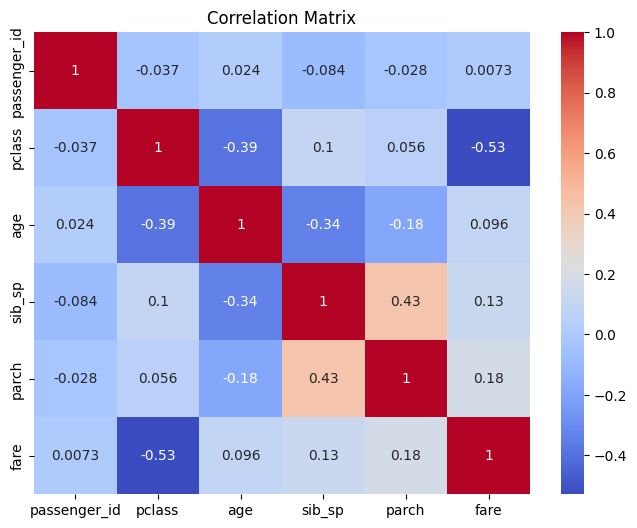

In [98]:

corr_matrix = train_df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

Overall, the predictors are mostly weakly correlated with each other. The two factors that are the most correlated are fare and pclass, and they are negatively correlated. This means that as fare rises, pclass decreases, which shows that first-class passengers generally paid higher fares. There is also a moderate negative correlation between age and pclass, as well as between sib_sp and age. In addition, there is a moderate positive correlation between parch and sib_sp, meaning that as parch increases, the sib_sp also increase. However, despite this, there are no extremely strong correlations between any predictors.

## Handling Missing Values With Imputers
When setting up a recipe for a model in R imputers can be utilized to handle missing values. In Scikit-learn we will also use imputers, but what exactly are imputers and what is imputation? Generally speaking, imputation is a step that can be taken in preprocessing to deal with missing values.

Expanding on this, imputation can be accomplished in several ways to varying degrees of complexity. On the simpler side, imputation can just be filling in missing values with the mean or median of non-missing values for qualitative variables and the mode for quantative variables. On the more complex side, we can use multivariate imputation where missing data can be filled in with k-nearest neighbors imputation or linear regression imputation for example. K-nearest neighbors imputation uses a k-nearest neighbors algorithm to find 'k' nearest observations to the data containing a missing value and fills it in with the average of that variable in the neighbors. Linear regression imputation fits a model with non-missing values and then predicts what the missing value should be from that.

As our data contains missing values, we will be using imputation in our preprocess function.

### Question 5

Create a preprocess function that does the following: 

* Imputate missing values using [IterativeImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html#sklearn.impute.IterativeImputer) from `sklearn.impute` with estimator = LinearRegression()
* Dummy code categorical variables
* Create interactions between
    * `sex` and `fare`
    * `age` and `fare`

Recall the following:
* Preprocessing should assume the prediction variable is not included
* A dataframe can be permanently modified by your function if you do not operate on a copy of it
* We need to store the column names prior to certain steps that return numpy arrays 

In [99]:
# Keep this line as its required to use the imputer
from sklearn.experimental import enable_iterative_imputer

# Import other functions here
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

imputer = IterativeImputer(estimator=LinearRegression())

def preprocess(titanic_data : pd.DataFrame, is_training : bool) -> pd.DataFrame:
    """
    Takes in titanic data and prepares it for usage in logistic regression modelling
    by dummy coding variables, creating interaction terms and imputing missing values.

    Args:
        titanic_data (pd.DataFrame) : The pandas dataframe containing the abalone dataset.
        is_training (bool) : A boolean that signifies if the imputer needs to be fit or not.
        
    Returns:
        titanic_processed (pd.DataFrame) : The processed titanic dataset, ready for modelling.
    """
    titanic_processed = titanic_data.copy()
    titanic_processed = pd.get_dummies(
        titanic_processed,
        columns=['sex'],
        drop_first=True
    )
    cols = titanic_processed.columns

    if is_training:
        titanic_processed = imputer.fit_transform(titanic_processed)
    else:
        titanic_processed = imputer.transform(titanic_processed)
    
    
    titanic_processed = pd.DataFrame(
        titanic_processed,
        columns=cols
    )
    titanic_processed['sex_male_fare'] = (
        titanic_processed['sex_male'] * titanic_processed['fare']
    )
    titanic_processed['age_fare'] = (
        titanic_processed['age'] * titanic_processed['fare']
    )

    return titanic_processed


## Updating The Outcome Variable

For logistic regression we want our outcome variable, `survived`, to change from yes or no to a 1 or 0. However, if we use pd.get_dummies to do this survived splits into two columns. To avoid this, we will make use of the pandas dataframe [.apply()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html) method and a lambda function. 

In python, lambda functions are small one-line functions that are usually used for simple operations or when passing a function as an argument to higher-order functions. In pandas lambda functions can be used in conjunction with the [.apply()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html) method to great effect.

Before moving on, something else we will want to use is a conditional expression. Conditional expressions allow us to easily output separate values depending on a condition and are usually of the form `val_if_true if condition else val_if_false`.

An example of a lambda function that uses a conditional expression is below, feel free to play around with it to get an idea of what it does!

In [100]:
is_two = lambda x : "X is 2!" if x == 2 else "X is not 2!"
print(is_two(2))
print(is_two(3))

X is 2!
X is not 2!


### Question 6

Create a lambda function called update_survived that returns 1 if x is 'Yes' or 0 otherwise. Then, in the **training** dataset, modify the column 'survived' using [.apply()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html). Afterwards, create a copy of the outcome variable `survived`, drop it from the training data and then place the training data into the preprocess function.  

Once preprocessed, initialize a logistic regression model for classification from [sklearn.linear_model.LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) with max_iter = 10000 and fit it with the training data. 

In [101]:
from sklearn.linear_model import LogisticRegression

update_survived = lambda x: 1 if x == 'Yes' else 0

train_df['survived'] = train_df['survived'].apply(update_survived)

y_train = train_df['survived'].copy()

X_train = train_df.drop(columns=['survived'])

X_train_processed = preprocess(X_train, is_training=True)

log_model = LogisticRegression(max_iter=10000)

log_model.fit(X_train_processed, y_train)

/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


### Question 7
Using the same processed data and outcome variable, initialize and fit a [linear discriminant analysis](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html) model for classification. 

In [102]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train_processed, y_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


### Question 8
Using the same processed data and outcome variable, initialize and fit a [quadratic discriminant analysis](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis.html) model for classification. 

In [103]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda_model = QuadraticDiscriminantAnalysis()

qda_model.fit(X_train_processed, y_train)

,priors,None
,reg_param,0.0
,store_covariance,False
,tol,0.0001


### Question 9
Using the same processed data and outcome variable, initialize and fit a [k-nearest neighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) model for classification. Choose a value of $k$ to try.

In [104]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_processed, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Question 10
Now that you've fit four different models to your training data, use the processed **training** data with [predict_proba()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.predict_proba) to generate predictions using each of these 4 models with the processed testing data. Then use the metric of area under the ROC curve to assess the performance of each of the four models. 

In Scikit-learn we use [predict_proba()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.predict_proba) to get probability estimates that will go into the ROC curve calculations. After using [predict_proba()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.predict_proba), subset it with [:, 1].

To determine the area under the ROC curve, use [roc_auc_score()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html) from `sklearn.metrics`. 



In [105]:
from sklearn.metrics import roc_auc_score

test_df['survived'] = test_df['survived'].apply(update_survived)

y_test = test_df['survived'].copy()
X_test = test_df.drop(columns=['survived'])
X_test_processed = preprocess(X_test, is_training=False)


log_pro = log_model.predict_proba(X_test_processed)[:, 1]
lda_pro = lda_model.predict_proba(X_test_processed)[:, 1]
qda_pro = qda_model.predict_proba(X_test_processed)[:, 1]
knn_pro = knn_model.predict_proba(X_test_processed)[:, 1]

print(roc_auc_score(y_test, log_pro))
print(roc_auc_score(y_test, lda_pro))
print(roc_auc_score(y_test, qda_pro))
print(roc_auc_score(y_test, knn_pro))

0.8519104084321476
0.8499341238471673
0.8693017127799737
0.6462450592885376


/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### Question 11
Preprocess your **testing** data, applying your lambda function, separating and then dropping the outcome variable, and putting the remaining data through the preprocess function. 

Fit all four models to your **testing** data and report the AUC of each model on the **testing** data. Which model achieved the highest AUC on the **testing** data?

Using your top-performing model, create a confusion matrix and visualize it. Create a plot of its ROC curve.

To create a plot of the ROC curve in Scikit-learn, we use [roc_curve()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html) from `sklearn.metrics` to get our true and false positive rates. Then to visualize the curve, use a matplotlib plot that takes in both rates.

To create a confusion matrix in Scikit-learn, we use [confusion_matrix()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) from `sklearn.metrics`, notice that we use predictions and not probability estimates for the confusion matrix. Then to visualize we use a seaborn heatmap with tick labels. 

How did your best model perform? Compare its **training** and **testing** AUC values. If the values differ, why do you think this is so?

0.8519104084321476
0.8499341238471673
0.8693017127799737
0.6462450592885376


/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/karla-12/Library/Python/3.10/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


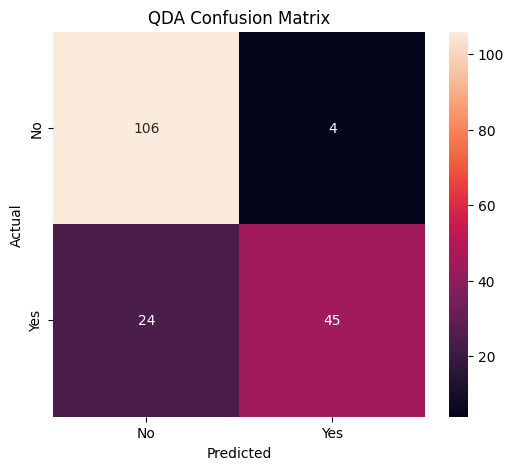

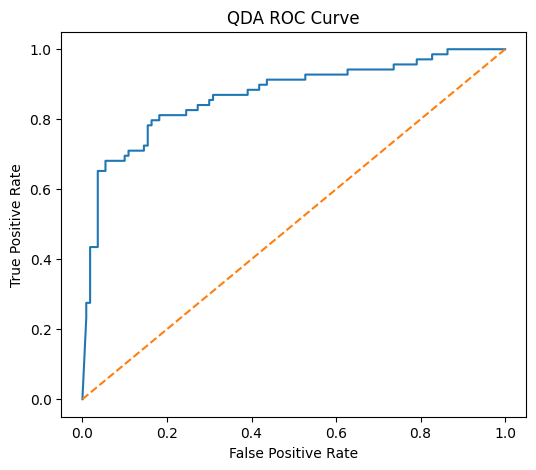

In [106]:

from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

y_test = test_df['survived'].copy()
X_test = test_df.drop(columns=['survived'])

X_test_processed = preprocess(X_test, is_training=False)

log_pro = log_model.predict_proba(X_test_processed)[:, 1]
lda_pro = lda_model.predict_proba(X_test_processed)[:, 1]
qda_pro = qda_model.predict_proba(X_test_processed)[:, 1]
knn_pro = knn_model.predict_proba(X_test_processed)[:, 1]

print(roc_auc_score(y_test, log_pro))
print(roc_auc_score(y_test, lda_pro))
print(roc_auc_score(y_test, qda_pro))
print(roc_auc_score(y_test, knn_pro))

qda_pred = qda_model.predict(X_test_processed)
cm = confusion_matrix(y_test, qda_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("QDA Confusion Matrix")
plt.show()


fpr, tpr, thresholds = roc_curve(y_test, qda_pro)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("QDA ROC Curve")
plt.show()

## Required for 231 Students
In a binary classification problem, let $p$ represent the probability of class label $1$, which implies that $1 - p$ represents the probability of class label $0$. The logistic function (also called the inverse logit) is the cumulative distribution function of the logistic distribution, which maps a real number z to the open interval $(0, 1)$.

### Question 12
Given that 
$p(z)=\frac{e^z}{1+e^z}$

Prove that the inverse of a logistic function is indeed the logit function:

$ z(p)=ln\left(\frac{p}{1-p}\right) $

### Question 13
Assume that $z = \beta_0 + \beta_{1}x_{1}$ and $p = logistic(z)$. How do the odds of the outcome change if you increase $x_{1}$ by two? Demonstrate this.

Assume now that $\beta_1$ is negative. What value does $p$ approach as $x_{1}$ approaches $\infty$? What value does $p$ approach as $x_{1}$ approaches $-\infty$? Demonstrate.